# Phase 3B.1 - Synthetic Data Generation for the Final 5-Mix Study Design

This notebook generates synthetic rating data for pipeline validation only. It uses the repository-confirmed final study configuration: two participant groups, two songs per group, five mix stimuli per song, three contextual scenarios, and 30 ratings per participant.

The ratings and effect sizes below are hypothetical simulation assumptions. They must not be interpreted as empirical listener evidence.

## 1. Imports and Reproducibility

The notebook uses a deterministic seed and does not fit a Bayesian model. Bambi/PyMC fitting starts in the next Phase 3B notebook.

In [1]:
from __future__ import annotations

import importlib.metadata as metadata
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RANDOM_SEED = 42
N_PARTICIPANTS = 40
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

versions = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
for package in ["matplotlib", "nbformat", "nbclient"]:
    try:
        versions[package] = metadata.version(package)
    except metadata.PackageNotFoundError:
        versions[package] = "not installed"

versions

{'python': '3.10.14',
 'numpy': '2.2.5',
 'pandas': '2.3.3',
 'matplotlib': '3.10.9',
 'nbformat': '5.10.4',
 'nbclient': '0.10.2'}

## 2. Repository-Relative Paths

The final study configuration is loaded from `study-interface/frontend-5mix/config`. Synthetic outputs are written under the consolidated statistical-baseline directory.

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    markers = [
        Path("study-interface/frontend-5mix/config/stimuli.json"),
        Path("outputs/stimulus_selection/11_five_mix_selection_review_20260806/five_mix_selection_traceability.csv"),
    ]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")

REPO_ROOT = find_repo_root()
CONFIG_DIR = REPO_ROOT / "study-interface" / "frontend-5mix" / "config"
STUDY_CONFIG_PATH = CONFIG_DIR / "study-config.json"
STIMULI_CONFIG_PATH = CONFIG_DIR / "stimuli.json"
TRACEABILITY_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "11_five_mix_selection_review_20260806" / "five_mix_selection_traceability.csv"
FEATURE_V2_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "processed_features_v2.csv"
FEATURE_BACKUP_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "08_backup_song_expansion" / "04_acoustic_candidate_pools" / "tables" / "processed_features_backup.csv"
OUTPUT_DIR = REPO_ROOT / "statistical-baseline" / "data" / "synthetic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

paths = pd.DataFrame(
    [
        {"label": "study_config", "path": STUDY_CONFIG_PATH},
        {"label": "stimuli_config", "path": STIMULI_CONFIG_PATH},
        {"label": "traceability", "path": TRACEABILITY_PATH},
        {"label": "features_v2", "path": FEATURE_V2_PATH},
        {"label": "features_backup", "path": FEATURE_BACKUP_PATH},
        {"label": "output_dir", "path": OUTPUT_DIR},
    ]
)
paths

,label,path
0,study_config,C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1....
1,stimuli_config,C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1....
2,traceability,C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1....
3,features_v2,C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1....
4,features_backup,C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1....
5,output_dir,C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1....


## 3. Load the Final Study Configuration

Groups, songs, episodes, mix IDs, and stimulus IDs are taken from the current frontend configuration rather than hard-coded legacy constants.

In [3]:
with STUDY_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    study_config = json.load(handle)
with STIMULI_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    stimuli_config = json.load(handle)

episodes = [scenario["id"] for scenario in stimuli_config["scenarios"]]
episode_labels = {scenario["id"]: scenario["title"] for scenario in stimuli_config["scenarios"]}
group_rows = stimuli_config["groups"]
group_to_excerpts = {group["id"]: list(group["excerptIds"]) for group in group_rows}
group_labels = {group["id"]: group.get("sourceAllocationLabel", group["id"]) for group in group_rows}

config_summary = pd.DataFrame(
    [
        {"item": "group_count", "value": len(group_rows)},
        {"item": "episodes", "value": " | ".join(episodes)},
        {"item": "excerpts_per_group", "value": study_config.get("excerptsPerGroup")},
        {"item": "mixes_per_trial", "value": study_config.get("mixesPerTrial")},
        {"item": "ratings_per_participant", "value": study_config.get("ratingsPerParticipant")},
        {"item": "rating_minimum", "value": study_config.get("ratingMinimum")},
        {"item": "rating_maximum", "value": study_config.get("ratingMaximum")},
    ]
)
config_summary

,item,value
0,group_count,2
1,episodes,EDR-1 | EDR-2 | FM-1
2,excerpts_per_group,2
3,mixes_per_trial,5
4,ratings_per_participant,30
5,rating_minimum,0
6,rating_maximum,100


## 4. Build the Final 20-Stimulus Metadata Table

The metadata table preserves participant-facing song labels, analytical song names, frontend mix IDs, stimulus IDs, and source mix labels.

In [4]:
stimulus_rows = []
for excerpt in stimuli_config["excerpts"]:
    group_id = excerpt["groupId"]
    for mix in excerpt["mixes"]:
        stimulus_rows.append(
            {
                "group": group_id,
                "group_label": group_labels[group_id],
                "excerpt_id": excerpt["id"],
                "song_id": excerpt["sourceSongId"],
                "song_title": excerpt["finalExcerptName"],
                "participant_song_label": excerpt["participantLabel"],
                "mix_slot": mix["slot"],
                "mix_id": mix["actualMixId"],
                "stimulus_id": mix["stimulusId"],
                "original_mix_name": mix["originalMixName"],
                "selection_category": mix.get("selectionCategory"),
                "analytical_role": mix.get("analyticalRole"),
                "frontend_audio_path": mix.get("audioPath"),
            }
        )

stimulus_metadata = pd.DataFrame(stimulus_rows).sort_values(["group", "excerpt_id", "mix_slot"]).reset_index(drop=True)

allocation_summary = (
    stimulus_metadata.groupby(["group", "group_label", "song_id", "song_title"], as_index=False)
    .agg(
        n_mixes=("mix_id", "nunique"),
        selected_mixes=("original_mix_name", lambda values: " | ".join(values)),
        stimulus_ids=("stimulus_id", lambda values: " | ".join(values)),
    )
)

display(allocation_summary)
display(stimulus_metadata[["group", "song_id", "song_title", "mix_slot", "mix_id", "stimulus_id", "original_mix_name"]])

,group,group_label,song_id,song_title,n_mixes,selected_mixes,stimulus_ids
0,group_01,Group A,id_like_to_know,I'd Like To Know,5,PXL-S3 | PXL-S5 | PXL-S1 | PXL-S2 | PXL-S7,id_like_to_know_pxl_s3 | id_like_to_know_pxl_s...
1,group_01,Group A,lead_me,Lead Me,5,DU-D | DU-E | PXL-L1 | PXL-L4 | McG-pro2,lead_me_du_d | lead_me_du_e | lead_me_pxl_l1 |...
2,group_02,Group B,in_the_meantime,In The Meantime,5,QUT-B | DU-H | DU-I | DU-K | QUT-pro,in_the_meantime_qut_b | in_the_meantime_du_h |...
3,group_02,Group B,pouring_room,Pouring Room,5,McG-R | McG-T | McG-X | McG-pro1 | McG-V,pouring_room_mcg_r | pouring_room_mcg_t | pour...


,group,song_id,song_title,mix_slot,mix_id,stimulus_id,original_mix_name
0,group_01,lead_me,Lead Me,mix_01,mix_f1f7973e5bac,lead_me_du_d,DU-D
1,group_01,lead_me,Lead Me,mix_02,mix_271852ba8676,lead_me_du_e,DU-E
2,group_01,lead_me,Lead Me,mix_03,mix_d5b28dfc8a93,lead_me_pxl_l1,PXL-L1
3,group_01,lead_me,Lead Me,mix_04,mix_c7d9a071ba25,lead_me_pxl_l4,PXL-L4
4,group_01,lead_me,Lead Me,mix_05,mix_d3e3580b6e30,lead_me_mcg_pro2,McG-pro2
5,group_01,id_like_to_know,I'd Like To Know,mix_01,mix_65f41f41d3ab,id_like_to_know_pxl_s3,PXL-S3
6,group_01,id_like_to_know,I'd Like To Know,mix_02,mix_82d60d7c7fc5,id_like_to_know_pxl_s5,PXL-S5
7,group_01,id_like_to_know,I'd Like To Know,mix_03,mix_9ffcd672af17,id_like_to_know_pxl_s1,PXL-S1
8,group_01,id_like_to_know,I'd Like To Know,mix_04,mix_6f8b655d7999,id_like_to_know_pxl_s2,PXL-S2
9,group_01,id_like_to_know,I'd Like To Know,mix_05,mix_b393d3919c78,id_like_to_know_pxl_s7,PXL-S7


## 5. Attach Raw Acoustic Metadata and Recompute Final Z-Scores

Raw scalar features are loaded from the two authoritative processed-feature tables identified in the Phase 3 audit. Z-scored predictors are recomputed jointly across the final 20 stimuli. `z_SI` is retained as an optional/QC-related sensitivity predictor; it is not automatically a primary predictor.

In [5]:
RAW_FEATURE_COLUMNS = ["rms_mean", "crest_factor_mean", "stereo_width", "stereo_imbalance"]
FEATURE_OUTPUT_COLUMNS = ["z_RMS", "z_CF", "z_SW", "z_SI"]
FEATURE_RENAME = {
    "rms_mean": "z_RMS",
    "crest_factor_mean": "z_CF",
    "stereo_width": "z_SW",
    "stereo_imbalance": "z_SI",
}

traceability = pd.read_csv(TRACEABILITY_PATH)
features_v2 = pd.read_csv(FEATURE_V2_PATH).assign(feature_source_file=str(FEATURE_V2_PATH.relative_to(REPO_ROOT)))
features_backup = pd.read_csv(FEATURE_BACKUP_PATH).assign(feature_source_file=str(FEATURE_BACKUP_PATH.relative_to(REPO_ROOT)))

feature_columns = [
    "song",
    "song_id",
    "mix_id",
    "original_mix_name",
    "feature_source_file",
    "stereo_imbalance_qc_only",
    "stereo_imbalance_qc_flag",
    *RAW_FEATURE_COLUMNS,
]
combined_features = pd.concat(
    [features_v2[feature_columns], features_backup[feature_columns]],
    ignore_index=True,
)

feature_subset = combined_features[combined_features["mix_id"].isin(stimulus_metadata["mix_id"])].copy()
if feature_subset["mix_id"].duplicated().any():
    duplicated = feature_subset.loc[feature_subset["mix_id"].duplicated(keep=False), ["mix_id", "song", "original_mix_name", "feature_source_file"]]
    raise ValueError(f"Duplicate feature rows found for final mix IDs:\n{duplicated}")

stimulus_metadata = stimulus_metadata.merge(
    feature_subset.drop(columns=["song_id", "song", "original_mix_name"]),
    on="mix_id",
    how="left",
    validate="one_to_one",
)

trace_cols = ["selected_mix_id", "feature_table_used", "feature_evidence", "technical_quality_status", "confidence_level", "manual_listening_confirmation_required"]
stimulus_metadata = stimulus_metadata.merge(
    traceability[trace_cols],
    left_on="mix_id",
    right_on="selected_mix_id",
    how="left",
    validate="one_to_one",
).drop(columns=["selected_mix_id"])

for raw_col, z_col in FEATURE_RENAME.items():
    mean = stimulus_metadata[raw_col].mean()
    sd = stimulus_metadata[raw_col].std(ddof=0)
    if not np.isfinite(sd) or sd == 0:
        raise ValueError(f"Cannot standardise {raw_col}: non-finite or zero standard deviation.")
    stimulus_metadata[z_col] = (stimulus_metadata[raw_col] - mean) / sd

stimulus_metadata["z_SI_role"] = "optional_qc_sensitivity_predictor"

feature_summary = stimulus_metadata[
    ["song_title", "original_mix_name", "stimulus_id", *RAW_FEATURE_COLUMNS, *FEATURE_OUTPUT_COLUMNS, "z_SI_role", "feature_source_file"]
]
feature_summary

,song_title,original_mix_name,stimulus_id,rms_mean,crest_factor_mean,stereo_width,stereo_imbalance,z_RMS,z_CF,z_SW,z_SI,z_SI_role,feature_source_file
0,Lead Me,DU-D,lead_me_du_d,0.062587,13.814332,0.117577,-0.052133,0.740286,-1.548717,0.328048,-1.017147,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
1,Lead Me,DU-E,lead_me_du_e,0.054377,19.253822,0.043004,0.043613,-1.025058,0.519995,-0.866608,0.995934,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
2,Lead Me,PXL-L1,lead_me_pxl_l1,0.059133,16.919521,0.017093,-0.012909,-0.002444,-0.367771,-1.281694,-0.192446,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
3,Lead Me,PXL-L4,lead_me_pxl_l4,0.058888,15.674652,0.149042,0.109931,-0.055201,-0.841212,0.832111,2.390300,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
4,Lead Me,McG-pro2,lead_me_mcg_pro2,0.073005,20.146322,0.039276,-0.001436,2.980531,0.859425,-0.926328,0.048774,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
5,I'd Like To Know,PXL-S3,id_like_to_know_pxl_s3,0.060649,15.086064,0.024367,-0.008429,0.323484,-1.065060,-1.165177,-0.098248,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...
6,I'd Like To Know,PXL-S5,id_like_to_know_pxl_s5,0.057478,17.484858,0.146867,0.073631,-0.358338,-0.152766,0.797271,1.627075,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...
7,I'd Like To Know,PXL-S1,id_like_to_know_pxl_s1,0.056513,16.363316,0.066817,0.060797,-0.565911,-0.579304,-0.485121,1.357248,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...
8,I'd Like To Know,PXL-S2,id_like_to_know_pxl_s2,0.061623,14.764206,0.049424,0.022453,0.533000,-1.187467,-0.763752,0.551037,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...
9,I'd Like To Know,PXL-S7,id_like_to_know_pxl_s7,0.055112,16.259357,0.076943,-0.053767,-0.867056,-0.618841,-0.322901,-1.051511,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...


## 6. Validate the Final Design Metadata

These checks fail loudly if the frontend configuration or acoustic metadata no longer match the final 5-mix design.

In [6]:
def check(name: str, observed, expected, passed: bool | None = None) -> dict:
    if passed is None:
        passed = observed == expected
    return {"check": name, "observed": observed, "expected": expected, "passed": bool(passed)}

metadata_checks = []
metadata_checks.append(check("Exactly 20 final stimuli", stimulus_metadata["stimulus_id"].nunique(), 20))
metadata_checks.append(check("Exactly 4 songs", stimulus_metadata["song_id"].nunique(), 4))
metadata_checks.append(check("Exactly 5 mixes per song", stimulus_metadata.groupby("song_id")["mix_id"].nunique().to_dict(), "all songs have 5", (stimulus_metadata.groupby("song_id")["mix_id"].nunique() == 5).all()))
metadata_checks.append(check("Exactly 2 participant groups", stimulus_metadata["group"].nunique(), 2))
metadata_checks.append(check("Exactly 3 episodes", len(episodes), 3))
metadata_checks.append(check("Exactly 2 songs per group", {g: len(v) for g, v in group_to_excerpts.items()}, "each group has 2", all(len(v) == 2 for v in group_to_excerpts.values())))
metadata_checks.append(check("Complete RMS feature coverage", int(stimulus_metadata["rms_mean"].notna().sum()), 20))
metadata_checks.append(check("Complete CF feature coverage", int(stimulus_metadata["crest_factor_mean"].notna().sum()), 20))
metadata_checks.append(check("Complete SW feature coverage", int(stimulus_metadata["stereo_width"].notna().sum()), 20))
metadata_checks.append(check("Complete SI feature coverage", int(stimulus_metadata["stereo_imbalance"].notna().sum()), 20))

for z_col in ["z_RMS", "z_CF", "z_SW", "z_SI"]:
    metadata_checks.append(check(f"{z_col} joint mean approximately 0", round(float(stimulus_metadata[z_col].mean()), 10), 0.0, np.isclose(stimulus_metadata[z_col].mean(), 0.0, atol=1e-10)))
    metadata_checks.append(check(f"{z_col} joint population SD approximately 1", round(float(stimulus_metadata[z_col].std(ddof=0)), 10), 1.0, np.isclose(stimulus_metadata[z_col].std(ddof=0), 1.0, atol=1e-10)))

metadata_validation = pd.DataFrame(metadata_checks)
display(metadata_validation)

if not metadata_validation["passed"].all():
    raise AssertionError("One or more final-design metadata checks failed.")

,check,observed,expected,passed
0,Exactly 20 final stimuli,20,20,True
1,Exactly 4 songs,4,4,True
2,Exactly 5 mixes per song,"{'id_like_to_know': 5, 'in_the_meantime': 5, '...",all songs have 5,True
3,Exactly 2 participant groups,2,2,True
4,Exactly 3 episodes,3,3,True
5,Exactly 2 songs per group,"{'group_01': 2, 'group_02': 2}",each group has 2,True
6,Complete RMS feature coverage,20,20,True
7,Complete CF feature coverage,20,20,True
8,Complete SW feature coverage,20,20,True
9,Complete SI feature coverage,20,20,True


## 7. Hypothetical Synthetic Generating Parameters

The synthetic data-generating process is additive and aligned with the final primary stimulus-based model:

`rating = grand_mean + group_effect + episode_effect + participant_intercept + stimulus_intercept + residual_noise`

These values are assumptions for pipeline testing only.

In [7]:
GRAND_MEAN = 66.0
GROUP_EFFECTS = {
    "group_01": 0.0,
    "group_02": 1.5,
}
EPISODE_EFFECTS = {
    "EDR-1": 2.0,
    "EDR-2": -1.5,
    "FM-1": 1.0,
}
PARTICIPANT_SD = 8.0
STIMULUS_SD = 5.0
RESIDUAL_SD = 10.0
RATING_MIN = 0.0
RATING_MAX = 100.0

participant_variance = PARTICIPANT_SD**2
stimulus_variance = STIMULUS_SD**2
residual_variance = RESIDUAL_SD**2
total_variance = participant_variance + stimulus_variance + residual_variance

variance_summary = pd.DataFrame(
    [
        {"component": "participant", "sd": PARTICIPANT_SD, "variance": participant_variance, "variance_share": participant_variance / total_variance},
        {"component": "stimulus", "sd": STIMULUS_SD, "variance": stimulus_variance, "variance_share": stimulus_variance / total_variance},
        {"component": "residual", "sd": RESIDUAL_SD, "variance": residual_variance, "variance_share": residual_variance / total_variance},
    ]
)

icc_summary = {
    "participant_variance": participant_variance,
    "stimulus_variance": stimulus_variance,
    "residual_variance": residual_variance,
    "total_variance": total_variance,
    "participant_ICC_true": participant_variance / total_variance,
    "stimulus_ICC_true": stimulus_variance / total_variance,
    "residual_share_true": residual_variance / total_variance,
}

generating_parameters = {
    "purpose": "Synthetic pipeline validation only; not empirical evidence.",
    "random_seed": RANDOM_SEED,
    "n_participants": N_PARTICIPANTS,
    "grand_mean": GRAND_MEAN,
    "group_effects": GROUP_EFFECTS,
    "episode_effects": EPISODE_EFFECTS,
    "participant_sd": PARTICIPANT_SD,
    "stimulus_sd": STIMULUS_SD,
    "residual_sd": RESIDUAL_SD,
    "rating_min": RATING_MIN,
    "rating_max": RATING_MAX,
    "primary_generator": "additive stimulus-based generator; no episode-by-stimulus or episode-by-feature interactions",
    "z_SI_role": "computed, but retained only as optional/QC-related sensitivity predictor",
    **icc_summary,
}

display(pd.DataFrame([generating_parameters]).T.rename(columns={0: "value"}))
display(variance_summary)

,value
purpose,Synthetic pipeline validation only; not empiri...
random_seed,42
n_participants,40
grand_mean,66.0
group_effects,"{'group_01': 0.0, 'group_02': 1.5}"
episode_effects,"{'EDR-1': 2.0, 'EDR-2': -1.5, 'FM-1': 1.0}"
participant_sd,8.0
stimulus_sd,5.0
residual_sd,10.0
rating_min,0.0


,component,sd,variance,variance_share
0,participant,8.0,64.0,0.338624
1,stimulus,5.0,25.0,0.132275
2,residual,10.0,100.0,0.529101


## 8. Assign Participants and Generate Rating-Level Data

Participants are assigned approximately equally to the two groups. Within every participant-song-episode trial, the presentation order of the five mixes is independently randomised.

In [8]:
participant_ids = [f"P{i:03d}" for i in range(1, N_PARTICIPANTS + 1)]
group_ids = list(group_to_excerpts.keys())
participant_groups = {
    participant_id: group_ids[index % len(group_ids)]
    for index, participant_id in enumerate(participant_ids)
}

participant_intercepts = pd.Series(
    rng.normal(loc=0.0, scale=PARTICIPANT_SD, size=N_PARTICIPANTS),
    index=participant_ids,
    name="participant_intercept",
)
stimulus_intercepts = pd.Series(
    rng.normal(loc=0.0, scale=STIMULUS_SD, size=len(stimulus_metadata)),
    index=stimulus_metadata["stimulus_id"],
    name="stimulus_intercept",
)

stimulus_lookup = stimulus_metadata.set_index("excerpt_id")
stimulus_by_id = stimulus_metadata.set_index("stimulus_id")
rows = []

for participant_id in participant_ids:
    group = participant_groups[participant_id]
    for excerpt_id in group_to_excerpts[group]:
        excerpt_stimuli = stimulus_metadata.loc[stimulus_metadata["excerpt_id"] == excerpt_id].copy()
        for episode in episodes:
            ordered_indices = rng.permutation(excerpt_stimuli.index.to_numpy())
            for order_position, row_index in enumerate(ordered_indices, start=1):
                stimulus = stimulus_metadata.loc[row_index]
                expected_rating = (
                    GRAND_MEAN
                    + GROUP_EFFECTS[group]
                    + EPISODE_EFFECTS[episode]
                    + participant_intercepts.loc[participant_id]
                    + stimulus_intercepts.loc[stimulus["stimulus_id"]]
                )
                rating = expected_rating + rng.normal(loc=0.0, scale=RESIDUAL_SD)
                rating = float(np.clip(rating, RATING_MIN, RATING_MAX))
                rows.append(
                    {
                        "participant_id": participant_id,
                        "group": group,
                        "song_id": stimulus["song_id"],
                        "song_title": stimulus["song_title"],
                        "mix_id": stimulus["mix_id"],
                        "stimulus_id": stimulus["stimulus_id"],
                        "original_mix_name": stimulus["original_mix_name"],
                        "episode": episode,
                        "episode_label": episode_labels[episode],
                        "presentation_order": order_position,
                        "expected_rating": expected_rating,
                        "rating": rating,
                        "comment": "Synthetic placeholder comment - real study requires a qualitative response.",
                        "rms_mean": stimulus["rms_mean"],
                        "crest_factor_mean": stimulus["crest_factor_mean"],
                        "stereo_width": stimulus["stereo_width"],
                        "stereo_imbalance": stimulus["stereo_imbalance"],
                        "z_RMS": stimulus["z_RMS"],
                        "z_CF": stimulus["z_CF"],
                        "z_SW": stimulus["z_SW"],
                        "z_SI": stimulus["z_SI"],
                        "z_SI_role": stimulus["z_SI_role"],
                    }
                )

ratings = pd.DataFrame(rows)
ratings.head()

,participant_id,group,song_id,song_title,mix_id,stimulus_id,original_mix_name,episode,episode_label,presentation_order,expected_rating,rating,comment,rms_mean,crest_factor_mean,stereo_width,stereo_imbalance,z_RMS,z_CF,z_SW,z_SI,z_SI_role
0,P001,group_01,lead_me,Lead Me,mix_f1f7973e5bac,lead_me_du_d,DU-D,EDR-1,EDR-1 - Enjoying Free Time,1,74.154007,80.016231,Synthetic placeholder comment - real study req...,0.062587,13.814332,0.117577,-0.052133,0.740286,-1.548717,0.328048,-1.017147,optional_qc_sensitivity_predictor
1,P001,group_01,lead_me,Lead Me,mix_271852ba8676,lead_me_du_e,DU-E,EDR-1,EDR-1 - Enjoying Free Time,2,73.153508,80.265774,Synthetic placeholder comment - real study req...,0.054377,19.253822,0.043004,0.043613,-1.025058,0.519995,-0.866608,0.995934,optional_qc_sensitivity_predictor
2,P001,group_01,lead_me,Lead Me,mix_d5b28dfc8a93,lead_me_pxl_l1,PXL-L1,EDR-1,EDR-1 - Enjoying Free Time,3,67.110188,75.043660,Synthetic placeholder comment - real study req...,0.059133,16.919521,0.017093,-0.012909,-0.002444,-0.367771,-1.281694,-0.192446,optional_qc_sensitivity_predictor
3,P001,group_01,lead_me,Lead Me,mix_c7d9a071ba25,lead_me_pxl_l4,PXL-L4,EDR-1,EDR-1 - Enjoying Free Time,4,71.598543,68.111293,Synthetic placeholder comment - real study req...,0.058888,15.674652,0.149042,0.109931,-0.055201,-0.841212,0.832111,2.390300,optional_qc_sensitivity_predictor
4,P001,group_01,lead_me,Lead Me,mix_d3e3580b6e30,lead_me_mcg_pro2,McG-pro2,EDR-1,EDR-1 - Enjoying Free Time,5,71.021166,66.397648,Synthetic placeholder comment - real study req...,0.073005,20.146322,0.039276,-0.001436,2.980531,0.859425,-0.926328,0.048774,optional_qc_sensitivity_predictor


## 9. Derive Trial-Level Highest-Rated Mixes

For each participant-song-episode trial, the five ratings are compared. Ties are not randomly broken; joint winners are retained using pipe-delimited identifiers and a long-format tie table.

In [9]:
trial_columns = ["participant_id", "group", "song_id", "episode"]
preference_rows = []
tie_long_rows = []

for trial_key, trial in ratings.groupby(trial_columns, sort=False):
    participant_id, group, song_id, episode = trial_key
    highest_rating = trial["rating"].max()
    winners = trial.loc[np.isclose(trial["rating"], highest_rating)].sort_values("presentation_order")
    is_tie = len(winners) > 1
    preference_rows.append(
        {
            "participant_id": participant_id,
            "group": group,
            "song_id": song_id,
            "episode": episode,
            "highest_rating": highest_rating,
            "highest_rated_mix": " | ".join(winners["mix_id"].astype(str)),
            "highest_rated_stimulus": " | ".join(winners["stimulus_id"].astype(str)),
            "is_tie": bool(is_tie),
            "n_joint_winners": int(len(winners)),
        }
    )
    if is_tie:
        for _, winner in winners.iterrows():
            tie_long_rows.append(
                {
                    "participant_id": participant_id,
                    "group": group,
                    "song_id": song_id,
                    "episode": episode,
                    "highest_rating": highest_rating,
                    "mix_id": winner["mix_id"],
                    "stimulus_id": winner["stimulus_id"],
                }
            )

trial_preferences = pd.DataFrame(preference_rows)
tie_long = pd.DataFrame(tie_long_rows, columns=["participant_id", "group", "song_id", "episode", "highest_rating", "mix_id", "stimulus_id"])

display(trial_preferences.head())
display(pd.DataFrame({"tie_trials": [int(trial_preferences["is_tie"].sum())], "tie_long_rows": [len(tie_long)]}))

,participant_id,group,song_id,episode,highest_rating,highest_rated_mix,highest_rated_stimulus,is_tie,n_joint_winners
0,P001,group_01,lead_me,EDR-1,80.265774,mix_271852ba8676,lead_me_du_e,False,1
1,P001,group_01,lead_me,EDR-2,72.492773,mix_d3e3580b6e30,lead_me_mcg_pro2,False,1
2,P001,group_01,lead_me,FM-1,78.409412,mix_271852ba8676,lead_me_du_e,False,1
3,P001,group_01,id_like_to_know,EDR-1,78.297616,mix_6f8b655d7999,id_like_to_know_pxl_s2,False,1
4,P001,group_01,id_like_to_know,EDR-2,69.535122,mix_6f8b655d7999,id_like_to_know_pxl_s2,False,1


,tie_trials,tie_long_rows
0,1,2


## 10. Validate Rating-Level and Trial-Level Structure

The checks below confirm the generated dataset uses the final 5-mix / 3-context structure and remains ready for the next Bayesian stimulus-model notebook.

In [10]:
validation_results = []
validation_results.extend(metadata_checks)

ratings_per_participant = ratings.groupby("participant_id").size()
songs_per_participant = ratings.groupby("participant_id")["song_id"].nunique()
candidates_per_trial = ratings.groupby(trial_columns).size()
observations_per_stimulus = ratings.groupby("stimulus_id").size()
participant_counts_by_group = pd.Series(participant_groups).value_counts().sort_index()
expected_rows = N_PARTICIPANTS * 2 * len(episodes) * 5
expected_trials = N_PARTICIPANTS * 2 * len(episodes)
expected_observations_per_stimulus = int((N_PARTICIPANTS / 2) * len(episodes))
expected_group_song_map = stimulus_metadata.groupby("group")["song_id"].unique().apply(lambda values: sorted(values)).to_dict()
observed_group_song_map = ratings.groupby("group")["song_id"].unique().apply(lambda values: sorted(values)).to_dict()

validation_results.extend(
    [
        check("Rating dataset has expected 1,200 rows", len(ratings), expected_rows),
        check("Preference dataset has expected 240 trial rows", len(trial_preferences), expected_trials),
        check("Exactly 30 ratings per participant", ratings_per_participant.unique().tolist(), [30], (ratings_per_participant == 30).all()),
        check("Exactly 2 songs per participant", songs_per_participant.unique().tolist(), [2], (songs_per_participant == 2).all()),
        check("Exactly 5 candidate stimuli per participant-song-episode trial", candidates_per_trial.unique().tolist(), [5], (candidates_per_trial == 5).all()),
        check("Presentation order is 1-5 within every trial", "validated", "1-5", ratings.groupby(trial_columns)["presentation_order"].apply(lambda s: sorted(s.tolist()) == [1, 2, 3, 4, 5]).all()),
        check("Correct group-to-song allocation", observed_group_song_map, expected_group_song_map, observed_group_song_map == expected_group_song_map),
        check("Ratings are between 0 and 100", [float(ratings["rating"].min()), float(ratings["rating"].max())], [0, 100], ratings["rating"].between(0, 100).all()),
        check("Comments are non-null", int(ratings["comment"].notna().sum()), len(ratings)),
        check("Every stimulus has expected repeated observations", observations_per_stimulus.unique().tolist(), [expected_observations_per_stimulus], (observations_per_stimulus == expected_observations_per_stimulus).all()),
        check("Every trial has unique winner or explicit tie", "validated", "unique winner or tie flag", (trial_preferences["n_joint_winners"] >= 1).all() and trial_preferences["is_tie"].equals(trial_preferences["n_joint_winners"] > 1)),
    ]
)

validation_summary = pd.DataFrame(validation_results).drop_duplicates(subset=["check"], keep="last").reset_index(drop=True)
display(validation_summary)

if not validation_summary["passed"].all():
    raise AssertionError("One or more synthetic-data validation checks failed.")

,check,observed,expected,passed
0,Exactly 20 final stimuli,20,20,True
1,Exactly 4 songs,4,4,True
2,Exactly 5 mixes per song,"{'id_like_to_know': 5, 'in_the_meantime': 5, '...",all songs have 5,True
3,Exactly 2 participant groups,2,2,True
4,Exactly 3 episodes,3,3,True
5,Exactly 2 songs per group,"{'group_01': 2, 'group_02': 2}",each group has 2,True
6,Complete RMS feature coverage,20,20,True
7,Complete CF feature coverage,20,20,True
8,Complete SW feature coverage,20,20,True
9,Complete SI feature coverage,20,20,True


## 11. Concise Report-Friendly Summaries

The following summaries describe the synthetic dataset and final feature table. They are descriptive checks, not empirical results.

In [11]:
dataset_summary = pd.DataFrame(
    [
        {"metric": "rating_rows", "value": len(ratings)},
        {"metric": "trial_preference_rows", "value": len(trial_preferences)},
        {"metric": "participants", "value": ratings["participant_id"].nunique()},
        {"metric": "participant_groups", "value": ratings["group"].nunique()},
        {"metric": "songs", "value": ratings["song_id"].nunique()},
        {"metric": "stimuli", "value": ratings["stimulus_id"].nunique()},
        {"metric": "episodes", "value": ratings["episode"].nunique()},
        {"metric": "ratings_per_participant", "value": ", ".join(map(str, sorted(ratings_per_participant.unique())))},
        {"metric": "observations_per_stimulus", "value": ", ".join(map(str, sorted(observations_per_stimulus.unique())))},
        {"metric": "rating_mean", "value": ratings["rating"].mean()},
        {"metric": "rating_sd", "value": ratings["rating"].std(ddof=1)},
        {"metric": "tie_trials", "value": int(trial_preferences["is_tie"].sum())},
    ]
)

mean_by_episode = ratings.groupby("episode", as_index=False)["rating"].agg(["mean", "std", "count"]).reset_index()
mean_by_group = ratings.groupby("group", as_index=False)["rating"].agg(["mean", "std", "count"]).reset_index()
mean_by_stimulus = ratings.groupby(["song_id", "stimulus_id", "original_mix_name"], as_index=False)["rating"].agg(["mean", "std", "count"]).reset_index()
final_feature_summary = stimulus_metadata[["song_id", "song_title", "mix_id", "stimulus_id", "original_mix_name", *RAW_FEATURE_COLUMNS, *FEATURE_OUTPUT_COLUMNS, "z_SI_role", "feature_source_file"]]

for title, table in [
    ("Dataset summary", dataset_summary),
    ("Participant counts by group", participant_counts_by_group.rename("n_participants").reset_index().rename(columns={"index": "group"})),
    ("Mean rating by episode", mean_by_episode),
    ("Mean rating by group", mean_by_group),
    ("Mean rating by stimulus", mean_by_stimulus.head(20)),
    ("Final feature summary", final_feature_summary),
]:
    print(f"\n{title}")
    display(table)


Dataset summary


,metric,value
0,rating_rows,1200
1,trial_preference_rows,240
2,participants,40
3,participant_groups,2
4,songs,4
5,stimuli,20
6,episodes,3
7,ratings_per_participant,30
8,observations_per_stimulus,60
9,rating_mean,67.6355



Participant counts by group


,group,n_participants
0,group_01,20
1,group_02,20



Mean rating by episode


...

,index,group,mean,std,count
0,0,group_01,69.514215,12.371946,600
1,1,group_02,65.756786,12.320998,600



Mean rating by stimulus


,index,song_id,stimulus_id,original_mix_name,mean,std,count
0,0,id_like_to_know,id_like_to_know_pxl_s1,PXL-S1,69.645410,12.416093,60
1,1,id_like_to_know,id_like_to_know_pxl_s2,PXL-S2,72.106993,12.477438,60
2,2,id_like_to_know,id_like_to_know_pxl_s3,PXL-S3,68.027102,12.291945,60
3,3,id_like_to_know,id_like_to_know_pxl_s5,PXL-S5,69.475152,10.928340,60
4,4,id_like_to_know,id_like_to_know_pxl_s7,PXL-S7,70.310083,13.577061,60
5,5,in_the_meantime,in_the_meantime_du_h,DU-H,70.271703,11.639265,60
6,6,in_the_meantime,in_the_meantime_du_i,DU-I,57.960539,13.816679,60
7,7,in_the_meantime,in_the_meantime_du_k,DU-K,65.502316,10.109763,60
8,8,in_the_meantime,in_the_meantime_qut_b,QUT-B,66.493565,10.705118,60
9,9,in_the_meantime,in_the_meantime_qut_pro,QUT-pro,65.592858,11.368469,60



Final feature summary


,song_id,song_title,mix_id,stimulus_id,original_mix_name,rms_mean,crest_factor_mean,stereo_width,stereo_imbalance,z_RMS,z_CF,z_SW,z_SI,z_SI_role,feature_source_file
0,lead_me,Lead Me,mix_f1f7973e5bac,lead_me_du_d,DU-D,0.062587,13.814332,0.117577,-0.052133,0.740286,-1.548717,0.328048,-1.017147,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
1,lead_me,Lead Me,mix_271852ba8676,lead_me_du_e,DU-E,0.054377,19.253822,0.043004,0.043613,-1.025058,0.519995,-0.866608,0.995934,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
2,lead_me,Lead Me,mix_d5b28dfc8a93,lead_me_pxl_l1,PXL-L1,0.059133,16.919521,0.017093,-0.012909,-0.002444,-0.367771,-1.281694,-0.192446,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
3,lead_me,Lead Me,mix_c7d9a071ba25,lead_me_pxl_l4,PXL-L4,0.058888,15.674652,0.149042,0.109931,-0.055201,-0.841212,0.832111,2.390300,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
4,lead_me,Lead Me,mix_d3e3580b6e30,lead_me_mcg_pro2,McG-pro2,0.073005,20.146322,0.039276,-0.001436,2.980531,0.859425,-0.926328,0.048774,optional_qc_sensitivity_predictor,outputs\stimulus_selection\04_mix_selection_v2...
5,id_like_to_know,I'd Like To Know,mix_65f41f41d3ab,id_like_to_know_pxl_s3,PXL-S3,0.060649,15.086064,0.024367,-0.008429,0.323484,-1.065060,-1.165177,-0.098248,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...
6,id_like_to_know,I'd Like To Know,mix_82d60d7c7fc5,id_like_to_know_pxl_s5,PXL-S5,0.057478,17.484858,0.146867,0.073631,-0.358338,-0.152766,0.797271,1.627075,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...
7,id_like_to_know,I'd Like To Know,mix_9ffcd672af17,id_like_to_know_pxl_s1,PXL-S1,0.056513,16.363316,0.066817,0.060797,-0.565911,-0.579304,-0.485121,1.357248,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...
8,id_like_to_know,I'd Like To Know,mix_6f8b655d7999,id_like_to_know_pxl_s2,PXL-S2,0.061623,14.764206,0.049424,0.022453,0.533000,-1.187467,-0.763752,0.551037,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...
9,id_like_to_know,I'd Like To Know,mix_b393d3919c78,id_like_to_know_pxl_s7,PXL-S7,0.055112,16.259357,0.076943,-0.053767,-0.867056,-0.618841,-0.322901,-1.051511,optional_qc_sensitivity_predictor,outputs\stimulus_selection\08_backup_song_expa...


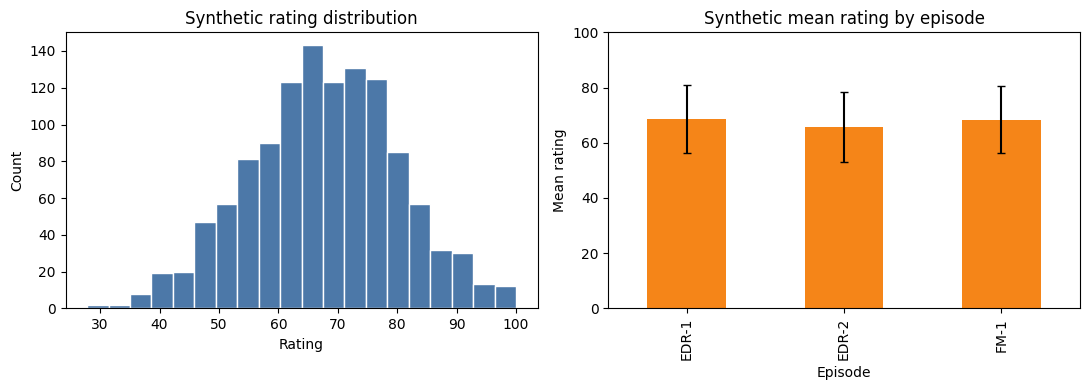

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ratings["rating"].plot(kind="hist", bins=20, ax=axes[0], color="#4C78A8", edgecolor="white")
axes[0].set_title("Synthetic rating distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

mean_by_episode.plot(kind="bar", x="episode", y="mean", yerr="std", ax=axes[1], color="#F58518", legend=False, capsize=3)
axes[1].set_title("Synthetic mean rating by episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Mean rating")
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 12. Export Synthetic Final-Design Outputs

Files are named explicitly as final 5-mix synthetic outputs to avoid confusing them with earlier historical synthetic outputs.

In [13]:
export_paths = {
    "final_5mix_stimulus_metadata": OUTPUT_DIR / "final_5mix_stimulus_metadata_seed42.csv",
    "final_5mix_synthetic_ratings": OUTPUT_DIR / "final_5mix_synthetic_ratings_seed42.csv",
    "final_5mix_trial_preferences": OUTPUT_DIR / "final_5mix_trial_preferences_seed42.csv",
    "final_5mix_trial_ties_long": OUTPUT_DIR / "final_5mix_trial_ties_long_seed42.csv",
    "final_5mix_validation_summary": OUTPUT_DIR / "final_5mix_validation_summary_seed42.csv",
    "final_5mix_generating_parameters": OUTPUT_DIR / "final_5mix_generating_parameters_seed42.json",
    "final_5mix_true_variance_icc": OUTPUT_DIR / "final_5mix_true_variance_icc_seed42.csv",
    "final_5mix_dataset_summary": OUTPUT_DIR / "final_5mix_dataset_summary_seed42.csv",
}

stimulus_metadata.to_csv(export_paths["final_5mix_stimulus_metadata"], index=False)
ratings.to_csv(export_paths["final_5mix_synthetic_ratings"], index=False)
trial_preferences.to_csv(export_paths["final_5mix_trial_preferences"], index=False)
tie_long.to_csv(export_paths["final_5mix_trial_ties_long"], index=False)
validation_summary.to_csv(export_paths["final_5mix_validation_summary"], index=False)
variance_summary.to_csv(export_paths["final_5mix_true_variance_icc"], index=False)
dataset_summary.to_csv(export_paths["final_5mix_dataset_summary"], index=False)
with export_paths["final_5mix_generating_parameters"].open("w", encoding="utf-8") as handle:
    json.dump(generating_parameters, handle, indent=2)

export_summary = pd.DataFrame([{"artifact": key, "path": str(path.relative_to(REPO_ROOT)), "exists": path.exists()} for key, path in export_paths.items()])
export_summary

,artifact,path,exists
0,final_5mix_stimulus_metadata,statistical-baseline\data\synthetic\final_5mix...,True
1,final_5mix_synthetic_ratings,statistical-baseline\data\synthetic\final_5mix...,True
2,final_5mix_trial_preferences,statistical-baseline\data\synthetic\final_5mix...,True
3,final_5mix_trial_ties_long,statistical-baseline\data\synthetic\final_5mix...,True
4,final_5mix_validation_summary,statistical-baseline\data\synthetic\final_5mix...,True
5,final_5mix_generating_parameters,statistical-baseline\data\synthetic\final_5mix...,True
6,final_5mix_true_variance_icc,statistical-baseline\data\synthetic\final_5mix...,True
7,final_5mix_dataset_summary,statistical-baseline\data\synthetic\final_5mix...,True


## 13. Limitations and Next Steps

The ratings in this notebook are synthetic and the effect sizes are hypothetical. The notebook validates the final 5-mix / 3-context study structure, exports a final 20-stimulus metadata table, and prepares data for the next notebook.

The next notebook will fit the final additive Bayesian stimulus model, including participant and stimulus random intercepts. ICC recovery will be evaluated there. Real participant data will later replace these synthetic ratings.

In [14]:
completion_report = {
    "notebook": "statistical-baseline/notebooks/_01_synthetic_data_generation.ipynb",
    "episodes": episodes,
    "songs": sorted(stimulus_metadata["song_title"].unique().tolist()),
    "n_stimuli": int(stimulus_metadata["stimulus_id"].nunique()),
    "feature_source_files": sorted(stimulus_metadata["feature_source_file"].dropna().unique().tolist()),
    "predictor_columns_created": FEATURE_OUTPUT_COLUMNS,
    "z_SI_role": "optional_qc_sensitivity_predictor",
    "rating_dataset_shape": ratings.shape,
    "preference_dataset_shape": trial_preferences.shape,
    "tie_count": int(trial_preferences["is_tie"].sum()),
    "participant_ICC_true": icc_summary["participant_ICC_true"],
    "stimulus_ICC_true": icc_summary["stimulus_ICC_true"],
    "all_validations_passed": bool(validation_summary["passed"].all()),
}
completion_report

{'notebook': 'statistical-baseline/notebooks/_01_synthetic_data_generation.ipynb',
 'episodes': ['EDR-1', 'EDR-2', 'FM-1'],
 'songs': ["I'd Like To Know", 'In The Meantime', 'Lead Me', 'Pouring Room'],
 'n_stimuli': 20,
 'feature_source_files': ['outputs\\stimulus_selection\\04_mix_selection_v2\\tables\\processed_features_v2.csv',
  'outputs\\stimulus_selection\\08_backup_song_expansion\\04_acoustic_candidate_pools\\tables\\processed_features_backup.csv'],
 'predictor_columns_created': ['z_RMS', 'z_CF', 'z_SW', 'z_SI'],
 'z_SI_role': 'optional_qc_sensitivity_predictor',
 'rating_dataset_shape': (1200, 22),
 'preference_dataset_shape': (240, 9),
 'tie_count': 1,
 'participant_ICC_true': 0.3386243386243386,
 'stimulus_ICC_true': 0.13227513227513227,
 'all_validations_passed': True}